### Import Libraries and Read in Data

In [34]:
# Import necessary libraries 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# Read in your data
df = pd.read_csv('salary_data_cleaned.csv')
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,avg_salary,company_text,job_state,same_state,age,python_yn,rstudio_yn,spark_yn,aws_yn,excel_yn
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,...,72.0,Tecolote Research\n,NM,0,53,1,0,0,0,1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,...,87.5,University of Maryland Medical System\n,MD,0,42,1,0,0,0,0
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,...,85.0,KnowBe4\n,FL,1,16,1,0,1,0,1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,...,76.5,PNNL\n,WA,1,61,1,0,0,0,0
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,...,114.5,Affinity Solutions\n,NY,1,28,1,0,0,0,1


In [36]:
# See column names
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_text', 'job_state', 'same_state', 'age', 'python_yn',
       'rstudio_yn', 'spark_yn', 'aws_yn', 'excel_yn'],
      dtype='object')

### More Data Cleaning

Clean up some things that we missed or forgot about last time before we look at the data.

In [37]:
def title_simplifier(title):
    """
    Parses out and simplifies the job title we're looking at.
    
    PARAMETERS:
        title - Job title 
    RETURNS:
        A tag indicating what kind of job we're looking at
    """
    if 'data scientist' in title.lower():
        return 'data scientist'
    elif 'data engineer' in title.lower():
        return 'data engineer'
    elif 'analyst' in title.lower():
        return 'analyst'
    elif 'machine learning' in title.lower():
        return 'mle'
    elif 'manager' in title.lower():
        return 'manager'
    elif 'director' in title.lower():
        return 'director'
    else:
        return 'na'


def seniority(title):
    """
    Parses out and indicates the seniority level of the job we're looking at.
    
    PARAMETERS:
        title - Job title
    RETURNS:
        A tag indicating the seniority level of the job we're looking at
    """
    if 'sr' in title.lower() or 'senior' in title.lower() or 'sr' in title.lower() or 'lead' in title.lower() or 'principal' in title.lower():
        return 'senior'
    elif 'jr' in title.lower() or 'jr.' in title.lower():
        return 'jr'
    else:
        return 'na'

In [38]:
# See how the jobs we got fall into different categories & see how many of them there are in each
df['job_simplified'] = df['Job Title'].apply(title_simplifier)
df.job_simplified.value_counts()

job_simplified
data scientist    279
na                184
data engineer     119
analyst           102
manager            22
mle                22
director           14
Name: count, dtype: int64

In [39]:
# See how seniority of jobs & see how many of them there are
df['seniority'] = df['Job Title'].apply(seniority)
df.seniority.value_counts()

seniority
na        520
senior    220
jr          2
Name: count, dtype: int64

In [40]:
# Fixed 'Los Angeles' being listed as a state
df['job_state'] = df.job_state.apply(lambda x: x.strip() if x.strip().lower() != 'los angeles' else 'CA')
df.job_state.value_counts()  # You can see that LA is not listed anymore

job_state
CA    152
MA    103
NY     72
VA     41
IL     40
MD     35
PA     33
TX     28
NC     21
WA     21
NJ     17
FL     16
OH     14
TN     13
DC     11
CO     11
WI     10
UT     10
IN     10
AZ      9
MO      9
AL      8
GA      6
DE      6
KY      6
MI      6
CT      5
IA      5
LA      4
OR      4
NE      4
NM      3
KS      3
ID      2
MN      2
RI      1
SC      1
Name: count, dtype: int64

In [41]:
# Create column for job description length
df['description_len'] = df['Job Description'].apply(lambda x: len(x))
df['description_len']

0       2536
1       4783
2       3461
3       3883
4       2728
5       3747
6       1786
7       3804
8       1538
9       4574
10      2757
11      3490
12      3934
13      4897
14      3731
15      1889
16      3639
17      4163
18      3512
19      4397
20      2918
21      6909
22      6408
23      2907
24      3760
25      3698
26      4420
27      4900
28      5015
29      3461
30      3883
31      3342
32      5045
33      2327
34      2161
35      1739
36      5000
37      3703
38      3555
39      1739
40      3053
41      1996
42      3833
43      3550
44      9120
45      3213
46      7286
47      3412
48      2682
49      2739
50      2915
51      4244
52      1629
53      4734
54      4448
55      3543
56      4203
57      5020
58      1786
59      3747
60      4804
61      1382
62      2933
63      4945
64      2493
65      1939
66      3081
67      8397
68      2306
69      2291
70      1886
71      2903
72      2653
73      4427
74      2609
75      4295
76      3405

In [42]:
# Create column for number of job competitors
df['num_competitors'] = df['Competitors'].apply(lambda x: len(x.split(',')) if x != '-1' else 0)
df.num_competitors

0      0
1      0
2      0
3      3
4      3
5      3
6      0
7      0
8      0
9      2
10     0
11     0
12     3
13     0
14     3
15     0
16     3
17     0
18     0
19     0
20     3
21     0
22     0
23     0
24     3
25     0
26     0
27     0
28     0
29     0
30     3
31     0
32     0
33     0
34     3
35     0
36     1
37     0
38     0
39     0
40     3
41     0
42     0
43     3
44     3
45     0
46     3
47     0
48     3
49     3
50     0
51     3
52     0
53     3
54     0
55     0
56     3
57     2
58     0
59     3
60     0
61     0
62     0
63     3
64     3
65     0
66     0
67     4
68     0
69     0
70     0
71     0
72     0
73     3
74     3
75     0
76     0
77     0
78     0
79     3
80     0
81     0
82     3
83     3
84     0
85     0
86     3
87     0
88     0
89     0
90     0
91     3
92     0
93     0
94     0
95     3
96     3
97     3
98     3
99     0
100    0
101    3
102    3
103    3
104    3
105    0
106    3
107    0
108    3
109    3
110    2
1

In [43]:
# Convert hourly wage to annual
# The units of the salaries are already in the thousands, so these numbers are just bases (e.g., 34 actually means 34K)
df['min_salary'] = df.apply(lambda x: x.min_salary * 2 if x.hourly == 1 else x.min_salary, axis=1)
df['max_salary'] = df.apply(lambda x: x.max_salary * 2 if x.hourly == 1 else x.max_salary, axis=1)
df[df.hourly == 1][['hourly', 'min_salary', 'max_salary']]

,hourly,min_salary,max_salary
165,1,34,48
177,1,42,68
197,1,36,50
202,1,42,68
210,1,30,50
246,1,34,48
271,1,42,68
337,1,36,50
345,1,48,78
357,1,42,68


In [44]:
# Remove new line character from job title
df['company_text'] = df.company_text.apply(lambda x: x.replace('\n', ''))
df['company_text']

0                                      Tecolote Research
1                  University of Maryland Medical System
2                                                KnowBe4
3                                                   PNNL
4                                     Affinity Solutions
5                                               CyrusOne
6                                     ClearOne Advantage
7                                             Logic20/20
8                              Rochester Regional Health
9                                               <intent>
10                                                  Wish
11                                               ManTech
12                                               Walmart
13                                                Yesler
14                                Takeda Pharmaceuticals
15                                               Audible
16                                   Blueprint Medicines
17                             

---
### Start of Exploratory Data Analysis

In [45]:
# Get a feeling for what the data looks like
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,742.0,469.129380,279.793117,0.0,221.5,472.5,707.75,955.0
Rating,742.0,3.618868,0.801210,-1.0,3.3,3.7,4.00,5.0
Founded,742.0,1837.154987,497.183763,-1.0,1939.0,1988.0,2007.00,2019.0
hourly,742.0,0.032345,0.177034,0.0,0.0,0.0,0.00,1.0
employer_provided,742.0,0.022911,0.149721,0.0,0.0,0.0,0.00,1.0
min_salary,742.0,74.719677,30.980593,15.0,52.0,69.5,91.00,202.0
max_salary,742.0,128.149596,45.220324,16.0,96.0,124.0,155.00,306.0
avg_salary,742.0,100.626011,38.855948,13.5,73.5,97.5,122.50,254.0
same_state,742.0,0.557951,0.496965,0.0,0.0,1.0,1.00,1.0
age,742.0,52.187332,54.156829,-1.0,17.0,30.0,65.00,282.0


#### Playing Around With Numerical Variables

<Axes: >

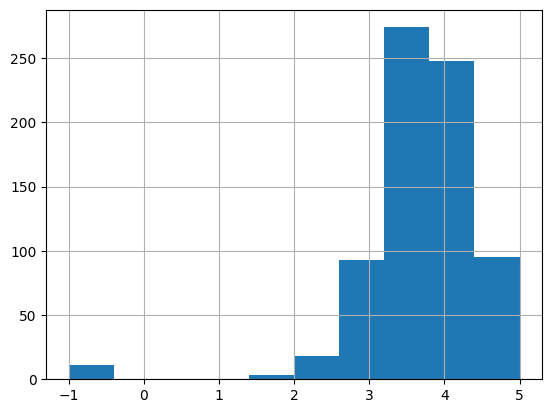

In [46]:
# Look at a very simple graph of the distribution of the 'Rating' column
df.Rating.hist()

<Axes: >

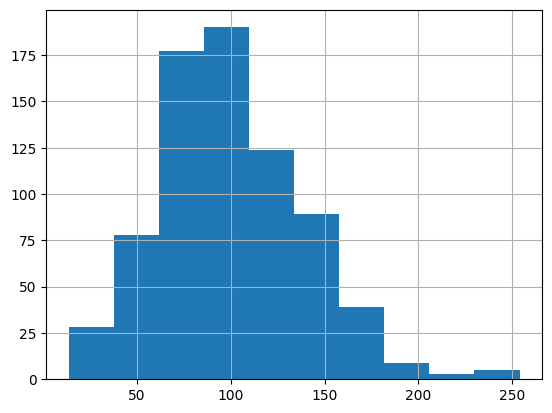

In [47]:
# Look at a very simple graph of the distribution of the 'avg_salary' column
df.avg_salary.hist()

<Axes: >

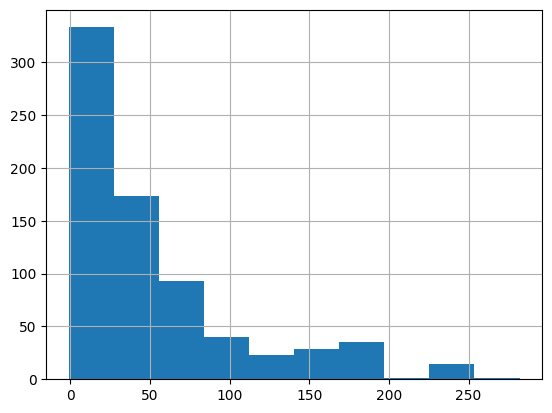

In [48]:
# Look at a very simple graph of the distribution of the 'age' column
df.age.hist()

Here, we note that age for a company is almost never normally distributed; it's exponential. When doing further analysis, feature engineering, or modeling, we may want to change this to make it into a more normal distribution.

<Axes: >

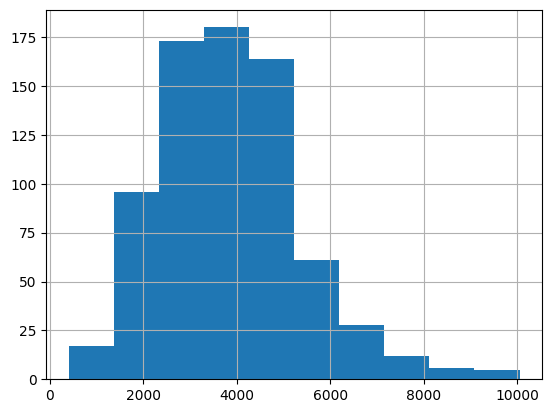

In [49]:
# Look at a very simple graph of the distribution of the 'description_len' column we made earlier
df.description_len.hist()

<Axes: >

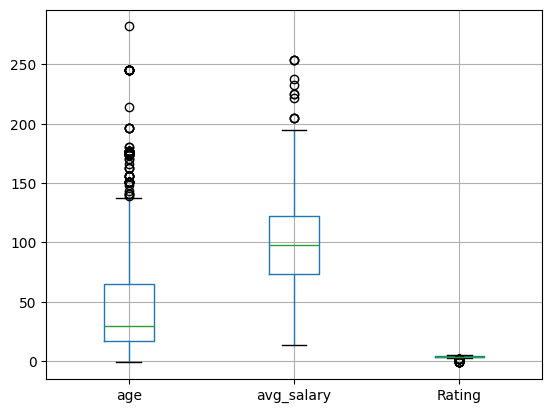

In [50]:
# Create a simple boxplot of some of the variables we already looked at
df.boxplot(column = ['age', 'avg_salary', 'Rating'])

<Axes: >

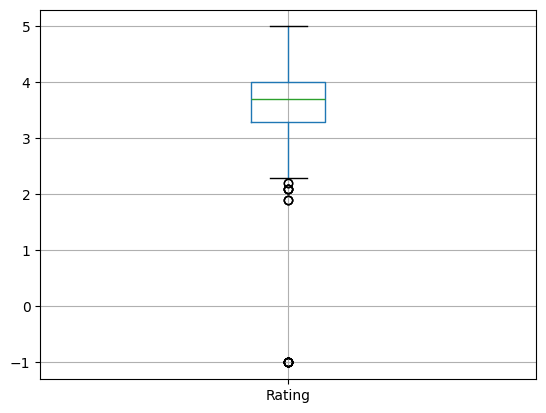

In [51]:
# Look at Rating specifically because it doesn't show up well when paired with the other two
df.boxplot(column = 'Rating')

Note that the "-1" really isn't an outlier. We purposefully made values -1 earlier for companies that didn't have a rating.

In [52]:
# Look at some correlations between variables
age_avgsalary_rate_desclen_corr = df[['age', 'avg_salary', 'Rating', 'description_len', 'num_competitors']].corr()
print(age_avgsalary_rate_desclen_corr)

                      age  avg_salary    Rating  description_len  \
age              1.000000    0.019163  0.030637         0.165514   
avg_salary       0.019163    1.000000  0.013492         0.078808   
Rating           0.030637    0.013492  1.000000        -0.012281   
description_len  0.165514    0.078808 -0.012281         1.000000   
num_competitors  0.131387    0.093813  0.027190         0.104620   

                 num_competitors  
age                     0.131387  
avg_salary              0.093813  
Rating                  0.027190  
description_len         0.104620  
num_competitors         1.000000  


<Axes: >

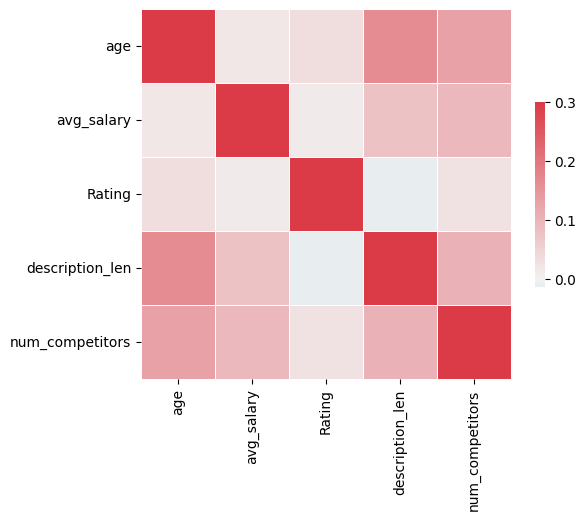

In [53]:
# Plot correlations
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(age_avgsalary_rate_desclen_corr, vmax=.3, center=0, cmap=cmap, square=True, linewidths=.5, cbar_kws={'shrink': .5})

From the visual, it looks like the strongest correlations are between age/description length and average salary/description length.

It also seems like older companies have more competitors, and description lengths are longer for companies with more competitors. 

#### Playing Around With Categorical Variables

In [54]:
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_text', 'job_state', 'same_state', 'age', 'python_yn',
       'rstudio_yn', 'spark_yn', 'aws_yn', 'excel_yn', 'job_simplified',
       'seniority', 'description_len', 'num_competitors'],
      dtype='object')

In [55]:
df_cat = df[['Location', 'Headquarters', 'Size', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'company_text', 'job_state', 'same_state',
   'python_yn', 'rstudio_yn', 'spark_yn', 'aws_yn', 'excel_yn', 'job_simplified', 'seniority']]

Graph for Total Number of Location: 200


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


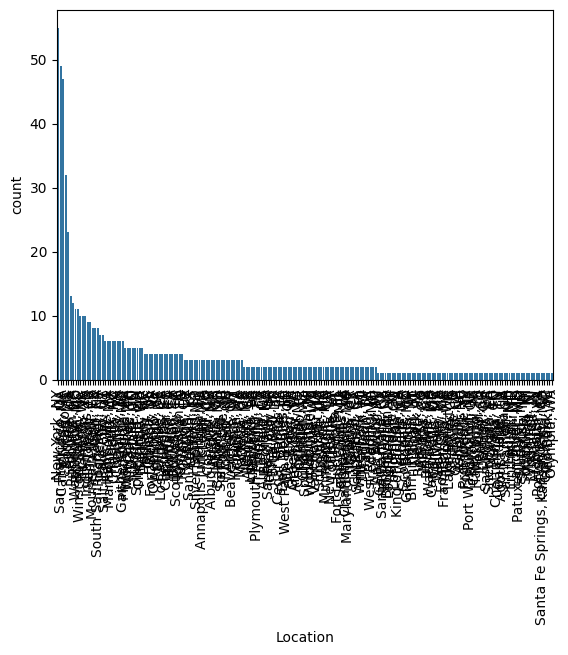

Graph for Total Number of Headquarters: 198


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


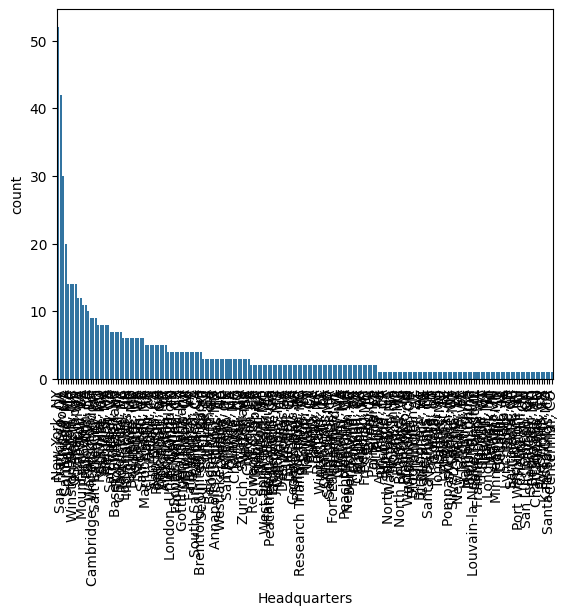

Graph for Total Number of Size: 9


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


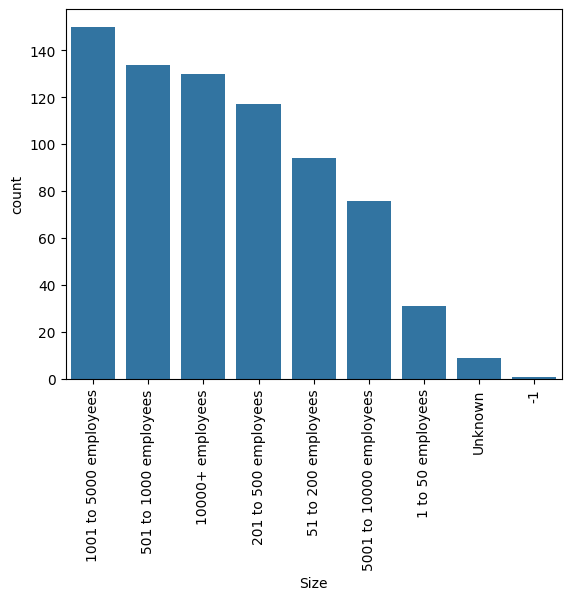

Graph for Total Number of Type of ownership: 11


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


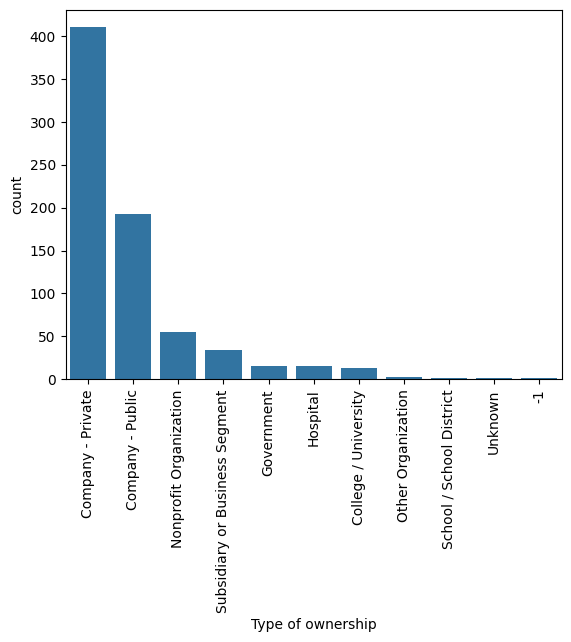

Graph for Total Number of Industry: 60


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


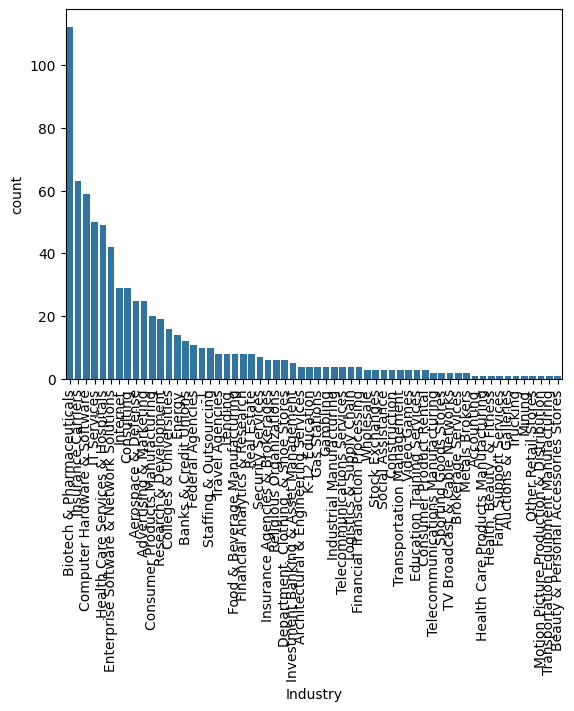

Graph for Total Number of Sector: 25


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


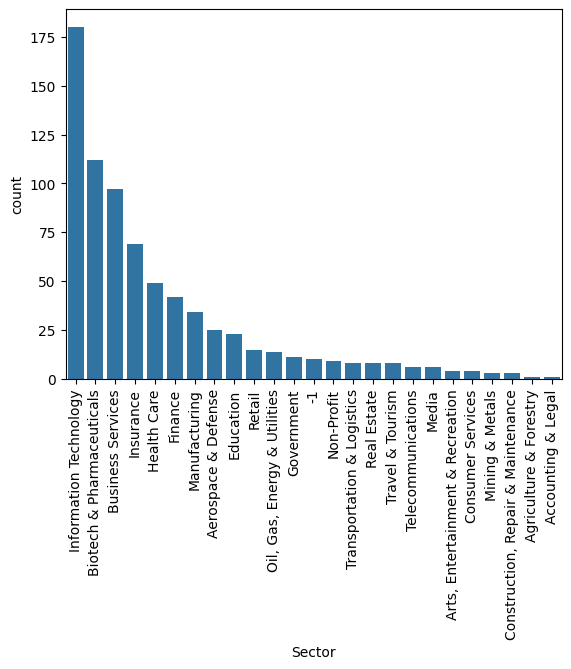

Graph for Total Number of Revenue: 14


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


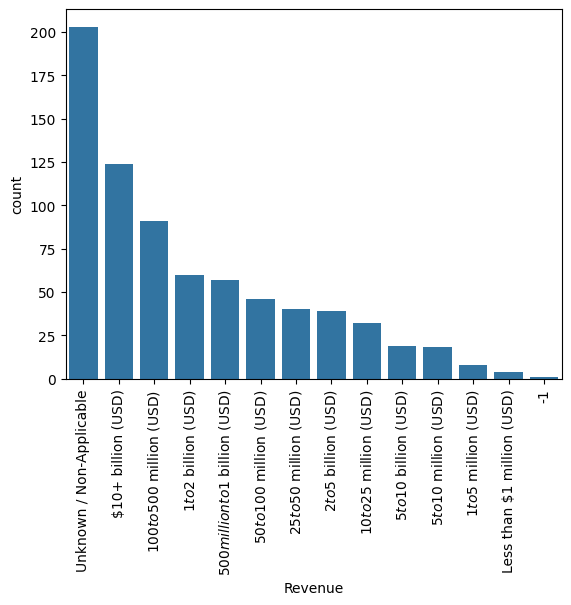

Graph for Total Number of company_text: 343


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


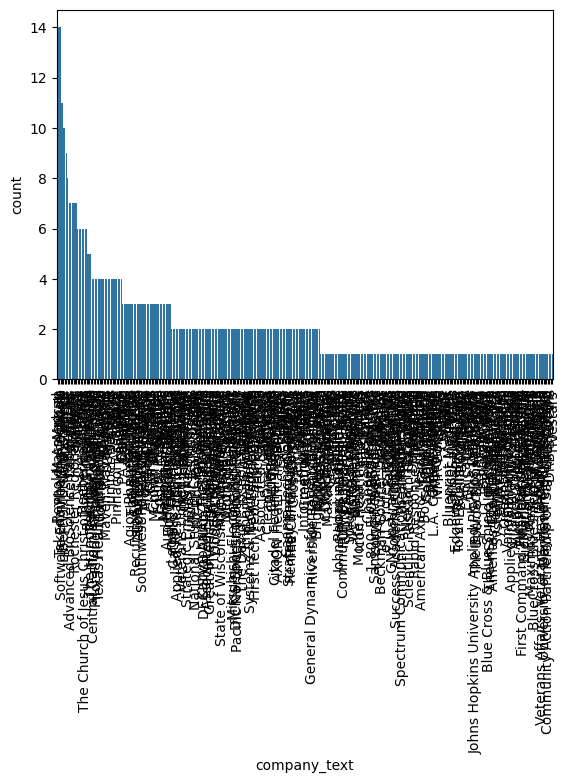

Graph for Total Number of job_state: 37


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


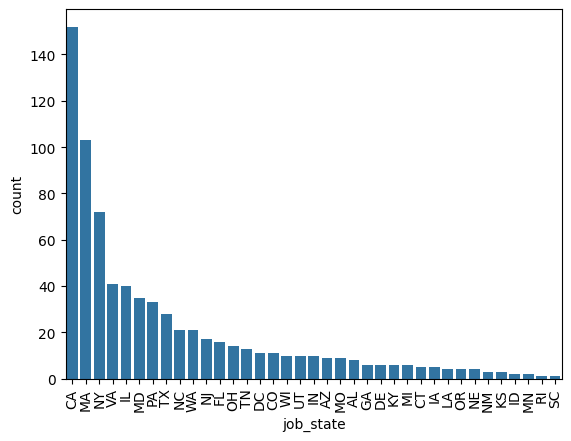

Graph for Total Number of same_state: 2


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


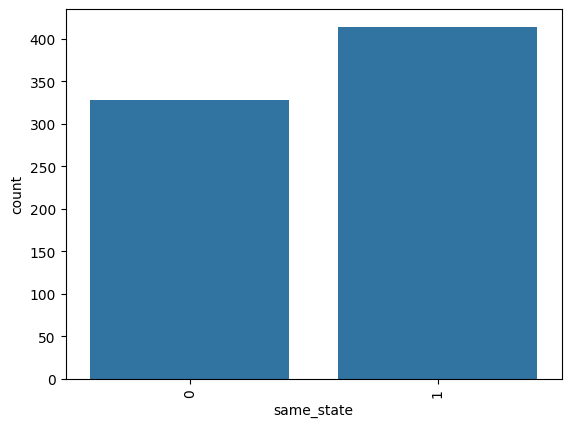

Graph for Total Number of python_yn: 2


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


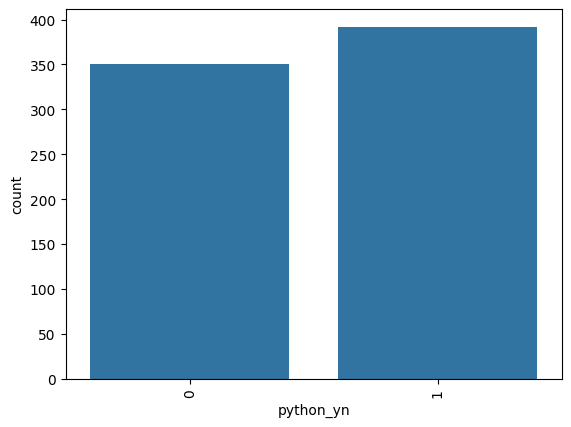

Graph for Total Number of rstudio_yn: 2


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


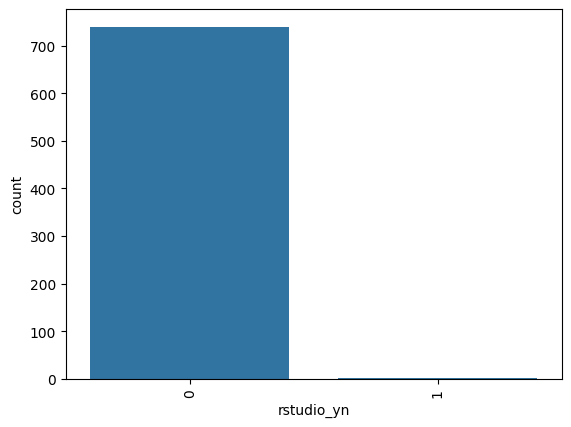

Graph for Total Number of spark_yn: 2


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


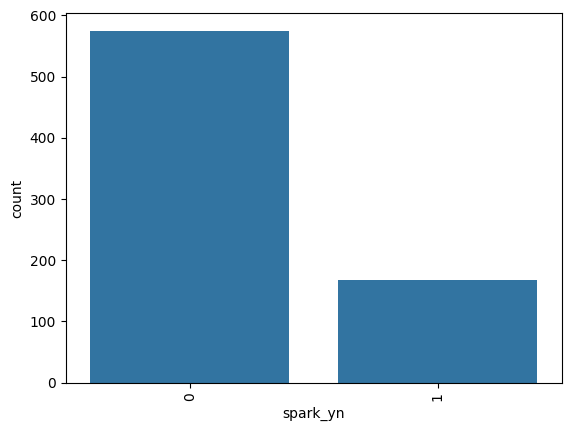

Graph for Total Number of aws_yn: 2


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


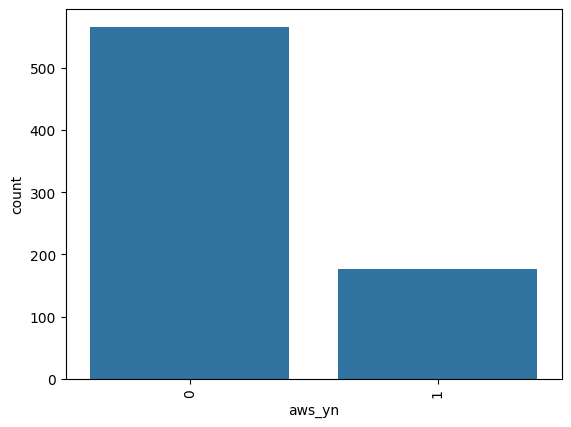

Graph for Total Number of excel_yn: 2


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


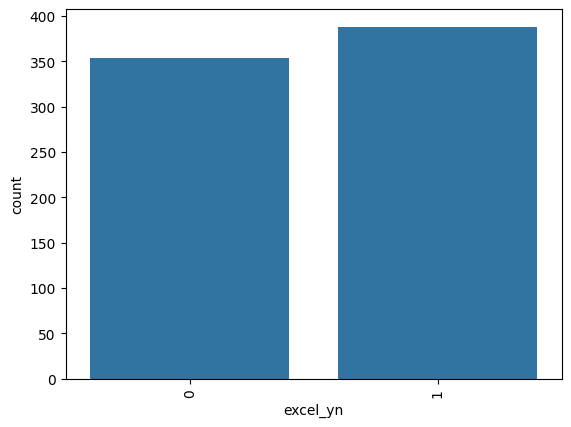

Graph for Total Number of job_simplified: 7


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


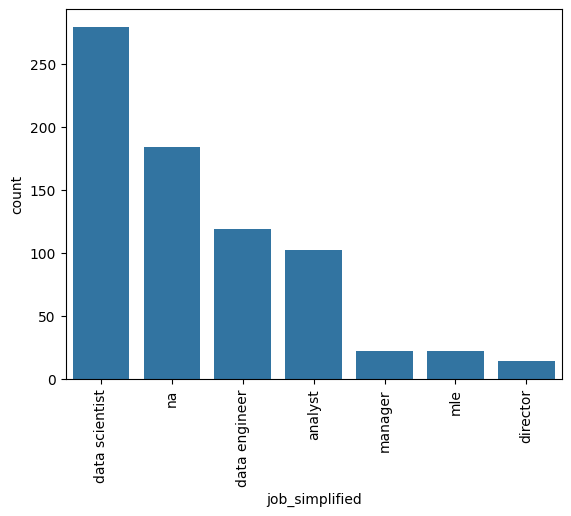

Graph for Total Number of seniority: 3


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\4119294314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


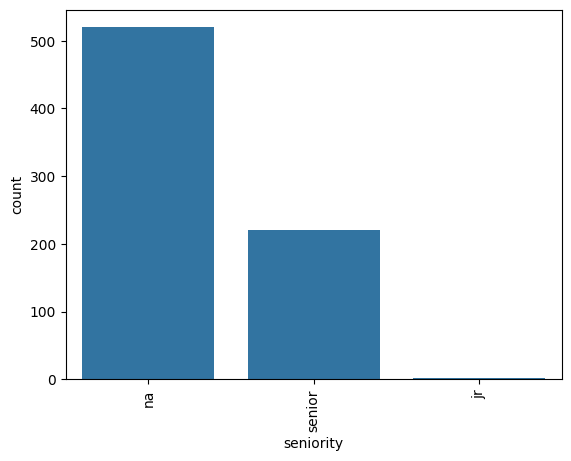

In [56]:
# Create some primitive grpahs, just to get an idea of the frequencies of each variable
for counter in df_cat.columns:
    cat_num = df_cat[counter].value_counts()
    print("Graph for Total Number of %s: %d" % (counter, len(cat_num)))
    chart = sns.barplot(x=cat_num.index, y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.show()

From the graphs we can interpret, we can notice some things:
- Most companies have 1000-5000 employees
- Private companies are the most common
- Information Technology, Biotech & Pharma, and Business Services are the biggest sectors for these ML/DS jobs
- The biggest companies (by revenue) are hiring the most data scientists
- CA, MA, NY, VA IL are hiring the most data scientists

Graph for Total Number of Location: 20


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\3609210243.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


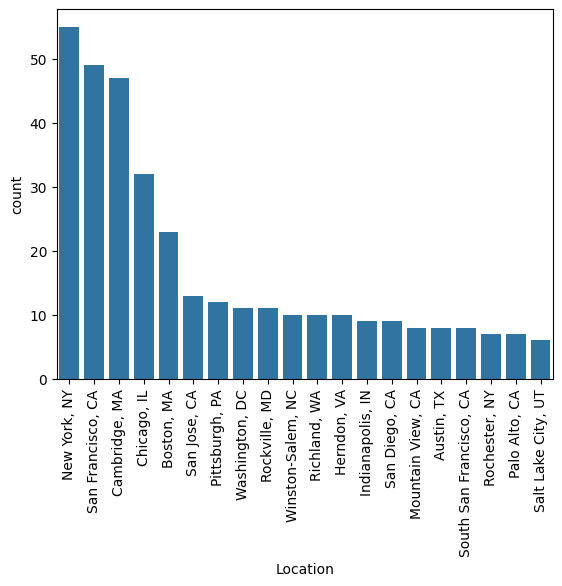

Graph for Total Number of Headquarters: 20


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\3609210243.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


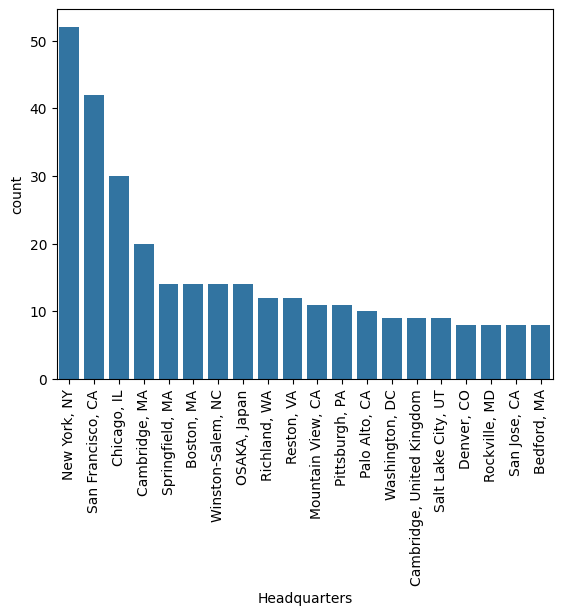

Graph for Total Number of company_text: 20


C:\Users\regmc\AppData\Local\Temp\ipykernel_204\3609210243.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


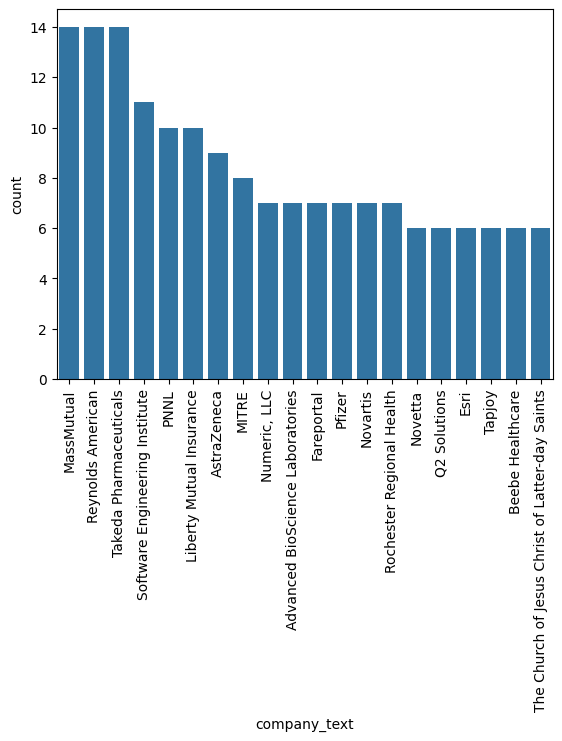

In [57]:
# Make some primitive graphs for the features that had a lot of values--the ones that were difficult to look at before
for counter in df[['Location', 'Headquarters', 'company_text']].columns:
    cat_num = df_cat[counter].value_counts()[:20]  # Instead of getting all values per feature, just get the top 20
    print("Graph for Total Number of %s: %d" % (counter, len(cat_num)))
    chart = sns.barplot(x=cat_num.index, y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.show()

From these visualizations we an see a few things:
- New York, San Francisco, and Cambridge have a ton of job postings
- Many HQs are in New York or San Francisco
- Companies that are hiring a lot include MassMutual and Reynolds American

#### Creating Pivot Tables

In [58]:
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_text', 'job_state', 'same_state', 'age', 'python_yn',
       'rstudio_yn', 'spark_yn', 'aws_yn', 'excel_yn', 'job_simplified',
       'seniority', 'description_len', 'num_competitors'],
      dtype='object')

In [59]:
# Check out the average salaries for each job category we made earlier
pd.pivot_table(df, index = 'job_simplified', values = 'avg_salary')

,avg_salary
job_simplified,
analyst,65.857843
data engineer,105.403361
data scientist,117.564516
director,168.607143
manager,84.022727
mle,126.431818
na,84.853261


It looks like data scientists, directors, and machine learning engineers are being paid the most. It's interesting to note that managers are being paid relatively low compare to those other jobs.

In [60]:
# Along with the job categories, group them up by seniority
pd.pivot_table(df, index = ['job_simplified', 'seniority'], values = 'avg_salary')

avg_salary
job_simplified seniority            
analyst        jr          56.500000
               na          61.155405
               senior      79.092593
data engineer  na          96.701220
               senior     124.689189
data scientist jr         106.500000
               na         107.043011
               senior     138.956522
director       na         168.607143
manager        na          84.022727
mle            na         119.133333
               senior     142.071429
na             na          73.988189
               senior     109.061404

It looks like senior data engineers make more than normal data scientists. Generally speaking, it looks like jobs with seniority get paid more. Analysts, in general, make less money.

In [61]:
# Get average salaries by state
pd.pivot_table(df, index = 'job_state', values = 'avg_salary').sort_values('avg_salary', ascending=False)

,avg_salary
job_state,
CA,123.513158
IL,116.662500
DC,110.181818
MA,106.281553
NJ,104.558824
MI,100.250000
RI,100.000000
NY,98.652778
NC,98.452381


CA, IL, DC, and MA have the highest average salaries. NY is surprisingly low, especially because the cost of living in NY is very high. Maybe they're hiring more data analysts than any other role? But let's take a look at that...

In [62]:
# Check out how many jobs there are for each job category for each state
pd.set_option('display.max_rows', None)  # Display all rows
pd.pivot_table(df, index = ['job_state', 'job_simplified'], values = 'avg_salary', aggfunc='count').sort_values('job_state', ascending=False)

avg_salary
job_state job_simplified            
WI        na                       4
          data scientist           3
          analyst                  3
WA        na                       1
          data scientist          17
          analyst                  3
VA        na                       5
          mle                      2
          data scientist          18
          data engineer           10
          analyst                  6
UT        data engineer            3
          analyst                  4
          data scientist           3
TX        na                       7
          data scientist          13
          data engineer            8
TN        data scientist           1
          data engineer           10
          analyst                  2
SC        na                       1
RI        analyst                  1
PA        manager                  3
          data engineer            1
          data scientist           6
          analyst                  8
          mle                      7
          na                       8
OR        data scientist           3
          data engineer            1
OH        na                       3
          data scientist           7
          analyst                  4
NY        na                      12
          mle                      2
          data scientist          40
          data engineer            4
          analyst                 14
NM        data scientist           3
NJ        data scientist           4
          analyst                  6
          data engineer            2
          manager                  2
          director                 2
          na                       1
NE        na                       4
NC        na                      12
          data scientist           3
          data engineer            6
MO        na                       3
          manager                  1
          data scientist           3
          analyst                  2
MN        data engineer            1
          analyst                  1
MI        manager                  2
          data scientist           4
MD        na                      16
          data scientist          13
          data engineer            3
          analyst                  3
MA        na                      46
          manager                  5
          director                 6
          data scientist          30
          data engineer           12
          analyst                  4
LA        analyst                  1
          data engineer            2
          na                       1
KY        na                       4
          data scientist           2
KS        mle                      3
IN        na                       4
          data scientist           2
          data engineer            4
IL        analyst                  3
          na                       6
          mle                      2
          director                 6
          data scientist          15
          data engineer            8
ID        analyst                  2
IA        analyst                  2
          data engineer            3
GA        data scientist           3
          na                       3
FL        data scientist           7
          data engineer            3
          analyst                  6
DE        na                       6
DC        data scientist           5
          data engineer            4
          analyst                  2
CT        na                       3
          data scientist           2
CO        mle                      1
          data engineer            3
          analyst                  1
          na                       3
          data scientist           3
CA        na                      27
          mle                      5
          manager                  9
          data scientist          68
          data engineer           25
          analyst             

From the looks of it, it looks like NY has 40 data scientists, 4 data engineers, and 14 analysts. CA has more analysts than NY at 18. IL is hiring more directors than either of the two, and overall has more diversity in the job categories.

In [63]:
# Get the average salary for each state for ONLY data scientist jobs
pd.pivot_table(df[df.job_simplified == 'data scientist'], index = 'job_state', values = 'avg_salary').sort_values('avg_salary', ascending=False)

,avg_salary
job_state,
DC,149.000000
CA,142.522059
UT,140.500000
MO,127.666667
IL,117.233333
NC,117.000000
NY,115.250000
MA,113.750000
WI,113.500000


DC is leading in the average data scientist salary. 

In [64]:
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_text', 'job_state', 'same_state', 'age', 'python_yn',
       'rstudio_yn', 'spark_yn', 'aws_yn', 'excel_yn', 'job_simplified',
       'seniority', 'description_len', 'num_competitors'],
      dtype='object')

In [65]:
df_pivot_tables = df[['Rating', 'Industry', 'Sector', 'Revenue', 'num_competitors', 'hourly', 
                    'employer_provided', 'python_yn', 'rstudio_yn', 'spark_yn', 'aws_yn', 'excel_yn', 
                    'Type of ownership', 'avg_salary']]


In [66]:
# Go through different categories and see how the average salaries rank in each category
for col in df_pivot_tables.columns:
    print(col)
    print(pd.pivot_table(df_pivot_tables, index = col, values = 'avg_salary').sort_values('avg_salary', ascending=False))
    print("\n--------------------------------------------------------------------------------------------------------------\n")

Rating
        avg_salary
Rating            
-1.0    136.181818
 5.0    134.700000
 2.5    120.000000
 4.5    117.714286
 4.1    116.368421
 3.9    113.071429
 2.6    109.083333
 4.4    108.606061
 3.2    105.500000
 4.0    105.340426
 3.5    104.897959
 3.7    104.131148
 4.7    103.983871
 4.3    102.468750
 3.3    101.858974
 4.2    100.442308
 2.2     97.750000
 4.6     97.250000
 3.8     96.811475
 2.1     95.900000
 3.4     93.011364
 1.9     87.500000
 3.1     86.580000
 3.0     85.588235
 3.6     85.467391
 2.8     83.928571
 2.7     83.250000
 2.3     81.500000
 2.9     81.138889
 4.8     80.277778
 2.4     60.214286

--------------------------------------------------------------------------------------------------------------

Industry
                                          avg_salary
Industry                                            
Other Retail Stores                       163.500000
Motion Picture Production & Distribution  146.000000
Financial Analytics & Research  

ValueError: Grouper for 'avg_salary' not 1-dimensional

From the above, we notice a few things:
- Companies with a 5/5 rating are offering the highest salary, followed by companies with 2.5/5 stars
- Retail, followed by Motion Pictures, pays the most when it comes to industry
- Construction and Non-Profits are pretty low when it comes to average salary; media and real-estate pay well
- Interestingly, companies that have lower revenue are paying the average salaries the most
- Companies with little competition pay better
- Hourly workers get paid worse
- Python, R, Spark, AWS, and Excel experience pay more
- Public and university companies are paying well

In [67]:
# Check number of users w/ experience in Python by company revenue
pd.pivot_table(df_pivot_tables, index ='Revenue', columns='python_yn', values='avg_salary', aggfunc = 'count')

python_yn,0,1
Revenue,,
$1 to $2 billion (USD),16.0,44.0
$1 to $5 million (USD),1.0,7.0
$10 to $25 million (USD),16.0,16.0
$10+ billion (USD),66.0,58.0
$100 to $500 million (USD),47.0,44.0
$2 to $5 billion (USD),17.0,22.0
$25 to $50 million (USD),24.0,16.0
$5 to $10 billion (USD),9.0,10.0
$5 to $10 million (USD),9.0,9.0


From this pivot table, we can see that companies with \\$1-2 billion in revenue hire more people with Python experience compared to the \\$50-100 million companies. 

#### Creating Word Clouds

In [68]:
!pip install wordcloud
from wordcloud import WordCloud, ImageColorGenerator, STOPWORDS
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


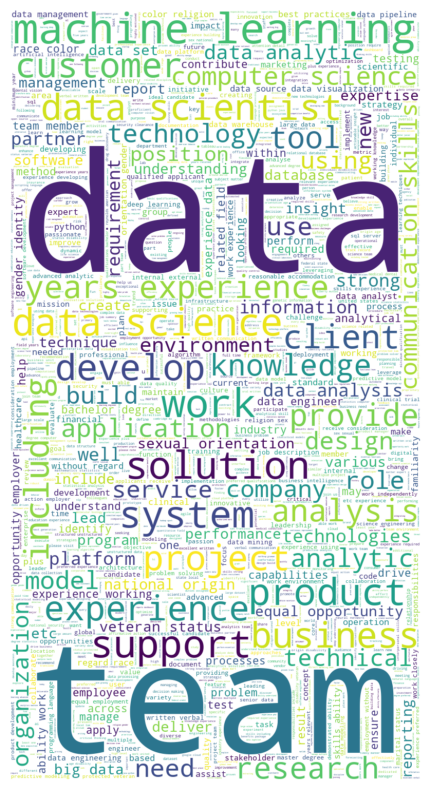

In [69]:
words = " ".join(df['Job Description'])

def punctuation_stop(text):
    """
    Tokenize the text and filter out words that are not part of the stopwords

    PARAMETERS:
        text - Target text (in this case, the job descriptions)
    RETURNS:
        List of filtered words that are not part of the stopwords list
    """
    filtered = []
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(text)
    for word in word_tokens:
        if word not in stop_words and word.isalpha():
            filtered.append(word.lower())
    return filtered

words_filtered = punctuation_stop(words)
text = " ".join([ele for ele in words_filtered])

wc = WordCloud(background_color="white", random_state=1, stopwords=STOPWORDS, max_words=2000, width=800, height=1500)
wc.generate(text)

plt.figure(figsize=[10, 10])
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

Based on the word cloud, the words "data," "team," "solution," and "machine learning" seem to be important words or phrases that are in the job descriptions from our dataset. Creating word clouds like this can provide us a greater understanding of what companies are looking for when it comes to hiring data scientists.

### Save DF with New Columns

In [70]:
file_path = 'data_after_eda.csv'
df.to_csv(file_path, index=False)